Libraries loaded ✓
Loaded 9,523 rows × 8 columns
=== Shape ===
(9523, 8)

=== Data Types ===
Product_Name        object
Brand               object
Category           float64
Variant_Details     object
Price              float64
SKU                 object
Available             bool
Updated_At          object
dtype: object

=== Missing Values ===
Category    9523
dtype: int64

=== Duplicate Rows ===
Duplicates: 0
Removed 0 duplicate rows → 9,523 remaining
Columns: ['product_name', 'brand', 'category', 'variant_details', 'price', 'sku', 'available', 'updated_at']
product_name nulls: 0
brand nulls after fill: 0
category nulls: 0
Distinct categories: 1
variant_details nulls (incl. 'Default Title'): 9,523
Zero/negative prices: 119 → set to NaN
Price range: RM 0.70 – RM 8900.00
Median price: RM 29.90
Rows with duplicate SKUs: 0
Available True: 7,981  |  False: 1,542
Date range: 2026-05-18 06:17:09+08:00 → 2026-05-18 06:18:10+08:00
updated_at nulls: 0

=== Missing Values After Cleaning ===
pro

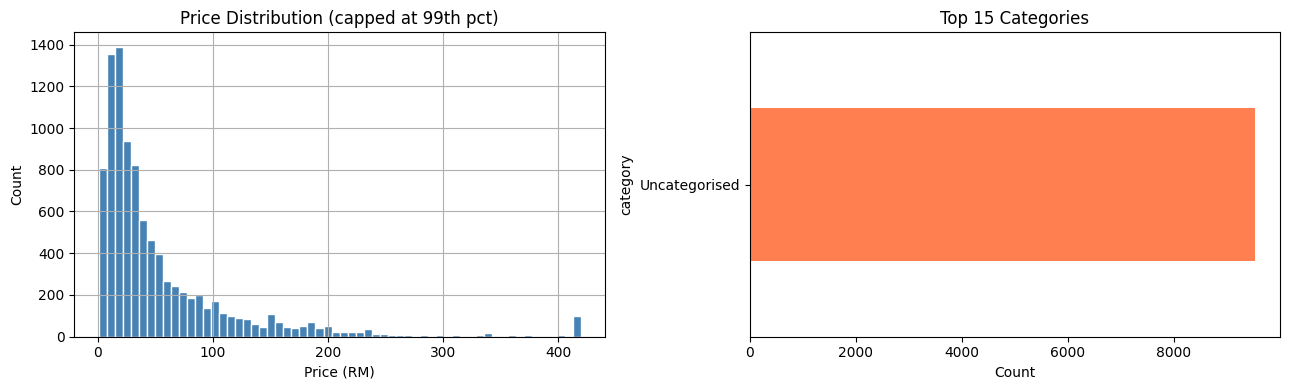

Saved → cleaned_data.csv  (1.1 MB)


In [2]:
# ============================================================
# Cell 1 — Install & Import
# ============================================================
!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, os

print("Libraries loaded ✓")

# ============================================================
# Cell 2 — Load Raw CSV
# ============================================================
RAW_PATH     = "/content/big_pharmacy_100k.csv"
CLEANED_PATH = "cleaned_data.csv"

df = pd.read_csv(RAW_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head()

# ============================================================
# Cell 3 — Initial Inspection
# ============================================================
print("=== Shape ===");         print(df.shape)
print("\n=== Data Types ===");  print(df.dtypes)
print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")
print(f"\n=== Duplicate Rows ===\nDuplicates: {df.duplicated().sum():,}")

# ============================================================
# Cell 4 — Drop Full Duplicates
# ============================================================
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df):,} duplicate rows → {len(df):,} remaining")

# ============================================================
# Cell 5 — Standardise Column Names
# ============================================================
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("Columns:", df.columns.tolist())

# ============================================================
# Cell 6 — Clean `product_name`
# ============================================================
df["product_name"] = (
    df["product_name"]
    .astype(str)
    .str.strip()
    .str.lower()
    # Collapse multiple spaces
    .str.replace(r"\s+", " ", regex=True)
    # Remove stray special characters (keep letters, digits, common punctuation)
    .str.replace(r"[^\w\s\-&%/().,+']", "", regex=True)
)
# Flag truly empty names
df.loc[df["product_name"].isin(["", "nan"]), "product_name"] = np.nan
print(f"product_name nulls: {df['product_name'].isna().sum():,}")

# ============================================================
# Cell 7 — Clean `brand`
# ============================================================
df["brand"] = (
    df["brand"]
    .astype(str)
    .str.strip()
    .str.title()                         # Title Case for readability
    .str.replace(r"\s+", " ", regex=True)
)
df.loc[df["brand"].isin(["", "Nan"]), "brand"] = np.nan

# Fill missing brand by extracting first word of product name (best-effort)
mask = df["brand"].isna() & df["product_name"].notna()
df.loc[mask, "brand"] = (
    df.loc[mask, "product_name"]
    .str.extract(r"^([a-z]+)", expand=False)
    .str.title()
)
print(f"brand nulls after fill: {df['brand'].isna().sum():,}")

# ============================================================
# Cell 8 — Clean `category`
# ============================================================
df["category"] = (
    df["category"]
    .astype(str)
    .str.strip()
    .str.title()
    .str.replace(r"\s+", " ", regex=True)
)
df.loc[df["category"].isin(["", "Nan"]), "category"] = np.nan

# Fill blank categories with 'Uncategorised'
df["category"] = df["category"].fillna("Uncategorised")
print(f"category nulls: {df['category'].isna().sum():,}")
print(f"Distinct categories: {df['category'].nunique()}")

# ============================================================
# Cell 9 — Clean `variant_details`
# ============================================================
df["variant_details"] = (
    df["variant_details"]
    .astype(str)
    .str.strip()
    .str.lower()
)
# "default title" is Shopify's placeholder — replace with NaN
df.loc[
    df["variant_details"].isin(["default title", "", "nan"]),
    "variant_details"
] = np.nan
print(f"variant_details nulls (incl. 'Default Title'): {df['variant_details'].isna().sum():,}")

# ============================================================
# Cell 10 — Clean `price`
# ============================================================
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)   # strip RM, commas, spaces
    .replace("", np.nan)
)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Remove zero / negative prices (invalid)
invalid_price = df["price"].le(0)
print(f"Zero/negative prices: {invalid_price.sum():,} → set to NaN")
df.loc[invalid_price, "price"] = np.nan

# Fill remaining NaN with median
median_price = df["price"].median()
df["price"] = df["price"].fillna(median_price)

print(f"Price range: RM {df['price'].min():.2f} – RM {df['price'].max():.2f}")
print(f"Median price: RM {median_price:.2f}")

# ============================================================
# Cell 11 — Clean `sku`
# ============================================================
df["sku"] = (
    df["sku"]
    .astype(str)
    .str.strip()
    .str.upper()
)
df.loc[df["sku"].isin(["", "NAN"]), "sku"] = np.nan

# Flag duplicate SKUs (same SKU, different rows — investigate)
dup_skus = df["sku"].duplicated(keep=False) & df["sku"].notna()
print(f"Rows with duplicate SKUs: {dup_skus.sum():,}")
df["sku_duplicate_flag"] = dup_skus   # keep for review; don't auto-drop

# ============================================================
# Cell 12 — Clean `available`
# ============================================================
# Coerce to proper boolean
df["available"] = (
    df["available"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False, "1": True, "0": False})
)
print(f"Available True: {df['available'].sum():,}  |  False: {(~df['available']).sum():,}")

# ============================================================
# Cell 13 — Clean `updated_at`
# ============================================================
df["updated_at"] = pd.to_datetime(df["updated_at"], errors="coerce", utc=True)
# Strip timezone offset for simpler downstream use (keep UTC)
df["updated_at"] = df["updated_at"].dt.tz_convert("Asia/Kuala_Lumpur")
print(f"Date range: {df['updated_at'].min()} → {df['updated_at'].max()}")
print(f"updated_at nulls: {df['updated_at'].isna().sum():,}")

# ============================================================
# Cell 14 — Final Missing Value Summary
# ============================================================
print("\n=== Missing Values After Cleaning ===")
print(df.isnull().sum())

# ============================================================
# Cell 15 — Validate Record Count
# ============================================================
print(f"\nFinal cleaned dataset: {len(df):,} rows")
assert len(df) >= 2000, f"⚠️ Only {len(df):,} records — need ≥ 2,000!"
print("✓ Record count OK")

# ============================================================
# Cell 16 — Visualise Key Distributions
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Price (clip top 1% to avoid long tail squishing the chart)
price_cap = df["price"].quantile(0.99)
df["price"].clip(upper=price_cap).hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Price Distribution (capped at 99th pct)")
axes[0].set_xlabel("Price (RM)")
axes[0].set_ylabel("Count")

# Top-N categories
top_cats = df["category"].value_counts().head(15)
top_cats.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Top 15 Categories")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("data_distributions.png", dpi=150)
plt.show()

# ============================================================
# Cell 17 — Save Cleaned Dataset
# ============================================================
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved → {CLEANED_PATH}  ({os.path.getsize(CLEANED_PATH)/1e6:.1f} MB)")